# 📊 INF01090 - Ciência de Dados - Regression Techniques

**House Prices - Advanced Regression Techniques - Kaggle-Style Competition**


## 🏁 Submission and Leaderboard

Submissions are evaluated in the local grading app:

<https://labo5inf01090-huzhzhojtbeqqknm7duabo.streamlit.app/>

The app expects a CSV file with exactly these columns:

```csv
Id,prediction
1461,210000
```


## $\S\, 0.$ Instalação e Importação de Dependências

In [25]:
%pip install --upgrade pip -q
%pip install numpy pandas scikit-learn scipy lightgbm catboost xgboost optuna seaborn matplotlib category_encoders -q

#   índice da submissão
y:int = 6;

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import category_encoders as ce

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Imports OK')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Imports OK


## $\S\, 1.$ Carregamento dos Dados
Carregamento dos dados `.csv` para DataFrames do `pandas` e breve análise exploratória dos dados, com `matplotlib+seaborn`.

In [26]:
train_df: pd.DataFrame = pd.read_csv("train_student.csv")
test_df:  pd.DataFrame = pd.read_csv("test_student.csv")

print("Dimensões (Treino): ", train_df.shape)
print("Test shape:",  test_df.shape)

train_df.head()
train_df.describe()

Dimensões (Treino):  (1022, 81)
Test shape: (438, 80)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1022.000000,1022.000000,832.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1019.000000,1022.000000,...,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000
mean,732.338552,57.059687,70.375000,10745.437378,6.128180,5.564579,1970.995108,1984.757339,105.261040,446.176125,...,97.548924,49.525440,21.303327,3.881605,15.565558,2.743640,41.565558,6.363992,2007.814090,181312.692759
std,425.860402,42.669715,25.533607,11329.753423,1.371391,1.110557,30.748816,20.747109,172.707705,459.971174,...,131.691873,69.205968,61.534380,32.547722,56.445749,39.671531,338.132358,2.650115,1.325807,77617.461005
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,367.500000,20.000000,59.000000,7564.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,735.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,390.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,165000.000000
75%,1100.500000,70.000000,80.000000,11692.500000,7.000000,6.000000,2001.000000,2004.000000,170.000000,724.000000,...,170.500000,73.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,8300.000000,12.000000,2010.000000,745000.000000


Breve análise exploratória dos dados, com `matplotlib+seaborn`: histogramas indicativos de _outliers_.

valores ausentes  em `train_df`:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      190
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


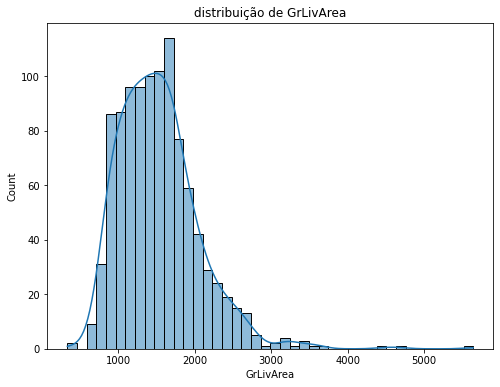

Column names: Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond

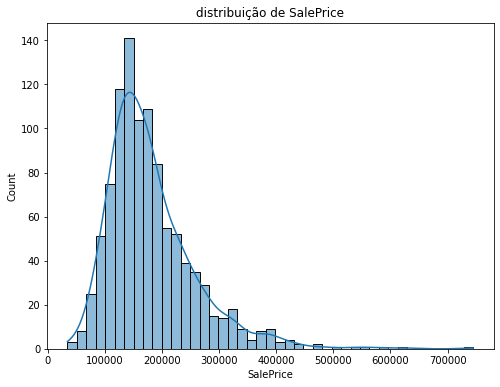

In [27]:
missing_values = train_df.isnull().sum()
print("valores ausentes  em `train_df`:")
print(missing_values)

column_name = "GrLivArea"
plt.figure(figsize=(8, 6))
sns.histplot(train_df["GrLivArea"], kde=True)
plt.title(f"distribuição de {column_name}")
plt.show()

# Print the column names
print("Column names:", train_df.columns)

# Select a valid column for plotting
column_name = "SalePrice"
plt.figure(figsize=(8, 6))
sns.histplot(train_df[column_name], kde=True)
plt.title(f"distribuição de {column_name}")
plt.show()

## $\S\, 2.$ Pré-Processamento
### $\S\, 2.1.$ Remoção de _Outliers_

In [28]:
# Remoção de outliers
train_df = train_df[train_df['GrLivArea'] < 4500]
train_df = train_df[~((train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 200_000))]
train_df = train_df[train_df['LotArea'] < 100_000]
train_df = train_df[train_df['TotalBsmtSF'] < 6000]
train_df = train_df[~((train_df['OverallQual'] <= 4) & (train_df['SalePrice'] > 300_000))]

### $\S\, 2.2.$ Explicitação da _Target_

In [29]:
X      = train_df.drop('SalePrice', axis=1).reset_index(drop=True)
y      = np.log1p(train_df['SalePrice']).reset_index(drop=True)
X_test = test_df.copy().reset_index(drop=True)

print(f'Dimensões - treino: {X.shape}, teste: {X_test.shape}')

Dimensões - treino: (1016, 80), teste: (438, 80)


### $\S\, 2.3.$ Correção de Tipos

In [30]:
def fix_dtypes(df):
    df = df.copy()
    # Estas colunas são categorias nominais, não números contínuos
    for col in ['MSSubClass', 'MoSold', 'YrSold']:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

X      = fix_dtypes(X)
X_test = fix_dtypes(X_test)

### $\S\, 2.4.$ Imputação de Valores Ausentes
Em `GarageYrBlt`: imputar com `0` gera um ano inválido que confunde o modelo. Imputamos com o ano de construção do imóvel (`YearBuilt`), que é a interpretação correta (garagem construída junto com a casa).

In [31]:
none_cols = ['Alley', 'MasVnrType', 'MiscFeature']
zero_cols = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
    'PoolArea', 'MiscVal', 'LotFrontage',
]

def impute_basic(df):
    df = df.copy()
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    if 'GarageYrBlt' in df.columns:
        mask = df['GarageYrBlt'].isna()
        df.loc[mask, 'GarageYrBlt'] = df.loc[mask, 'YearBuilt']
    return df

X      = impute_basic(X)
X_test = impute_basic(X_test)

### $\S\, 2.5.$ Engenharia de _Features_
#### $\S\, 2.5.1$ _Encoding_ Ordinal
Variáveis de qualidade (`Ex > Gd > TA > Fa > Po`) são mapeadas para inteiros antes de entrar no pipeline, para que o modelo respeite a ordem natural.

In [32]:
QUALITY_MAP      = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}
FINISH_MAP       = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
EXPOSURE_MAP     = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
SHAPE_MAP        = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
SLOPE_MAP        = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
UTILITY_MAP      = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1}
FUNCT_MAP        = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
GARAGE_FINISH_MAP= {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
FENCE_MAP        = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}

def apply_ordinals(df):
    df = df.copy()
    mappings = {
        'ExterQual': QUALITY_MAP,   'ExterCond': QUALITY_MAP,
        'BsmtQual':  QUALITY_MAP,   'BsmtCond':  QUALITY_MAP,
        'HeatingQC': QUALITY_MAP,   'KitchenQual': QUALITY_MAP,
        'FireplaceQu': QUALITY_MAP, 'GarageQual': QUALITY_MAP,
        'GarageCond':  QUALITY_MAP, 'PoolQC':    QUALITY_MAP,
        'BsmtFinType1': FINISH_MAP, 'BsmtFinType2': FINISH_MAP,
        'BsmtExposure': EXPOSURE_MAP,
        'LotShape':  SHAPE_MAP,     'LandSlope': SLOPE_MAP,
        'Utilities': UTILITY_MAP,   'Functional': FUNCT_MAP,
        'GarageFinish': GARAGE_FINISH_MAP,
        'Fence':     FENCE_MAP,
    }
    for col, mapping in mappings.items():
        if col in df.columns:
            df[col] = df[col].fillna('None').map(mapping).fillna(0).astype(int)
    return df

X      = apply_ordinals(X)
X_test = apply_ordinals(X_test)

### $\S\, 2.5.2$ Criação de Novas _Features_
São criadas features derivadas em 7 grupos:
- **Áreas agregadas** (soma de andares, banheiros, varandas)
- **Temporais** (idade da casa, tempo desde reforma)
- **Flags binárias** (tem piscina, garagem, lareira...)
- **Interações multiplicativas** (qualidade × área)
- **Log-transforms** para reduzir assimetria
- **Razões** (proporção de área por cômodo)
- **Scores compostos** (qualidade exterior × condição, lareira × quantidade)

In [33]:
def add_features(df):
    df = df.copy()

    # --- Áreas agregadas ---
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                            df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['TotalPorchSF']   = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                            df['3SsnPorch']   + df['ScreenPorch'])
    df['GarageScore']    = df['GarageCars'] * df['GarageArea']

    # --- Temporais ---
    df['HouseAge']       = df['YrSold'].astype(int) - df['YearBuilt']
    df['RemodAge']       = df['YrSold'].astype(int) - df['YearRemodAdd']
    df['TimeSinceRemod'] = df['YrSold'].astype(int) - df['YearRemodAdd']   # alias explícito

    # --- Flags binárias ---
    df['HasPool']       = (df['PoolArea']    > 0).astype(int)
    df['Has2ndFloor']   = (df['2ndFlrSF']    > 0).astype(int)
    df['HasGarage']     = (df['GarageArea']  > 0).astype(int)
    df['HasBsmt']       = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace']  = (df['Fireplaces']  > 0).astype(int)
    df['IsRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew']         = (df['YrSold'].astype(int) == df['YearBuilt']).astype(int)
    df['HasMasVnr']     = (df['MasVnrArea']   > 0).astype(int)
    df['HasPorch']      = (df['TotalPorchSF'] > 0).astype(int)

    # --- Interações multiplicativas ---
    df['OverallQual_TotalSF']   = df['OverallQual'] * df['TotalSF']
    df['OverallQual_GrLivArea'] = df['OverallQual'] * df['GrLivArea']
    df['OverallQual_sq']        = df['OverallQual'] ** 2
    df['OverallCond_sq']        = df['OverallCond'] ** 2
    df['GrLivArea_sq']          = df['GrLivArea'] ** 2
    df['TotalSF_sq']            = df['TotalSF'] ** 2
    df['QualCondScore']         = df['OverallQual'] * df['OverallCond']
    df['QualAge']               = df['OverallQual'] / df['HouseAge'].clip(lower=1)

    # --- Log-transforms ---
    df['LotAreaLog']    = np.log1p(df['LotArea'])
    df['GrLivAreaLog']  = np.log1p(df['GrLivArea'])
    df['TotalSFLog']    = np.log1p(df['TotalSF'])
    df['GarageAreaLog'] = np.log1p(df['GarageArea'])

    # --- Razões ---
    df['LivAreaRatio']  = df['GrLivArea']   / df['TotalSF'].clip(lower=1)
    df['BsmtRatio']     = df['TotalBsmtSF'] / df['TotalSF'].clip(lower=1)
    df['GarageRatio']   = df['GarageArea']  / df['GrLivArea'].clip(lower=1)
    df['LotFrontRatio'] = df['LotFrontage'].fillna(0) / df['LotArea'].clip(lower=1)

    # --- NOVAS: Razões de área por cômodo ---
    df['BsmtFinRatio']   = df['BsmtFinSF1'] / df['TotalBsmtSF'].clip(lower=1)
    df['LotAreaPerRoom'] = df['LotArea'] / df['TotRmsAbvGrd'].clip(lower=1)
    df['SFPerRoom']      = df['GrLivArea'] / df['TotRmsAbvGrd'].clip(lower=1)

    # --- NOVAS: Scores compostos (qualidade × quantidade/condição) ---
    df['ExterScore']      = df['ExterQual'] * df['ExterCond']
    df['KitchenScore']    = df['KitchenQual'] * df['GrLivArea']
    df['FireScore']       = df['FireplaceQu'] * df['Fireplaces']
    df['BsmtScore']       = df['BsmtExposure'] * df['BsmtQual']
    df['GarageFullScore'] = df['GarageQual'] * df['GarageCars']

    # --- NOVA: Interação imóvel novo × qualidade ---
    df['NewAndQual'] = df['IsNew'] * df['OverallQual']

    # --- Sazonalidade de venda (usando a string do MoSold) ---
    mo = df['MoSold'].astype(int)
    df['SaleSeasonQ1'] = mo.isin([1, 2, 3]).astype(int)
    df['SaleSeasonQ2'] = mo.isin([4, 5, 6]).astype(int)
    df['SaleSeasonQ3'] = mo.isin([7, 8, 9]).astype(int)
    df['SaleSeasonQ4'] = mo.isin([10, 11, 12]).astype(int)

    return df

X      = add_features(X)
X_test = add_features(X_test)
print(f'Features após engenharia: {X.shape[1]}')

Features após engenharia: 125


### $\S\, 2.5.3$ Separação de _Features_ Numéricas $\times$ Categóricas

In [34]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'Features Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)}')

print("Features categóricas:")
for feature in cat_cols: print(f"\t\t\t{feature}")

Features Numéricas: 98 | Categóricas: 27
Features categóricas:
			MSSubClass
			MSZoning
			Street
			Alley
			LandContour
			LotConfig
			Neighborhood
			Condition1
			Condition2
			BldgType
			HouseStyle
			RoofStyle
			RoofMatl
			Exterior1st
			Exterior2nd
			MasVnrType
			Foundation
			Heating
			CentralAir
			Electrical
			GarageType
			PavedDrive
			MiscFeature
			MoSold
			YrSold
			SaleType
			SaleCondition


## $\S\, 3.$ Busca de Hiperparâmetros com `Optuna`
### Observações
1. Esta célula realiza a busca bayesiana de hiperparâmetros para o `CatBoost` e `LightGBM`.
2. A busca de hiperparâmetros é um processo lento. Idealmente, deve ser feita apenas uma vez (digamos, durante a primeira execução do _notebook_) e ter seus resultados salvos.
3. Os resultados foram salvos em `....`
4. Se a _flag_ `RUN_TUNING` for falsa, esta secção é ignorada. Isto é recomendado para toda execução após a primeira.

In [35]:
RUN_TUNING = True

best_cat_params  = None
best_lgb_params  = None

if RUN_TUNING:
    # Precisamos de uma versão pré-processada de X para o Optuna
    # (usamos apenas as colunas numéricas para agilizar)
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import RobustScaler

    _imp = SimpleImputer(strategy='median')
    _sc  = RobustScaler()
    X_num_proc = _sc.fit_transform(_imp.fit_transform(X[num_cols]))

    # --- Tuning CatBoost ---
    print('Tuning CatBoost...')
    def cat_objective(trial):
        params = dict(
            iterations          = trial.suggest_int('iterations', 3000, 10000, step=1000),
            learning_rate       = trial.suggest_float('learning_rate', 0.002, 0.02, log=True),
            depth               = trial.suggest_int('depth', 4, 8),
            l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
            bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.5),
            border_count        = trial.suggest_categorical('border_count', [64, 128, 254]),
            random_strength     = trial.suggest_float('random_strength', 0.5, 5.0),
            random_seed         = 42,
            verbose             = 0,
        )
        cv  = KFold(n_splits=5, shuffle=True, random_state=42)
        oof = np.zeros(len(y))
        for tr_idx, val_idx in cv.split(X_num_proc):
            m = CatBoostRegressor(**params)
            m.fit(X_num_proc[tr_idx], y.iloc[tr_idx],
                  eval_set=(X_num_proc[val_idx], y.iloc[val_idx]),
                  early_stopping_rounds=300)
            oof[val_idx] = m.predict(X_num_proc[val_idx])
        return np.sqrt(mean_squared_error(y, oof))

    study_cat = optuna.create_study(direction='minimize')
    study_cat.optimize(cat_objective, n_trials=50, show_progress_bar=True)
    best_cat_params = study_cat.best_params
    print(f'\nMelhor RMSE CatBoost (Optuna): {study_cat.best_value:.6f}')
    print(f'Melhores params: {best_cat_params}')

    # --- Tuning LightGBM ---
    print('\nTuning LightGBM...')
    from lightgbm import early_stopping as lgb_es, log_evaluation as lgb_log
    def lgb_objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int('n_estimators', 3000, 10000, step=1000),
            learning_rate     = trial.suggest_float('learning_rate', 0.002, 0.02, log=True),
            num_leaves        = trial.suggest_int('num_leaves', 15, 63),
            max_depth         = trial.suggest_int('max_depth', 4, 8),
            subsample         = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_samples = trial.suggest_int('min_child_samples', 10, 50),
            reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 1.0),
            reg_lambda        = trial.suggest_float('reg_lambda', 0.0, 3.0),
            random_state      = 42, n_jobs=-1, verbose=-1,
        )
        cv  = KFold(n_splits=5, shuffle=True, random_state=42)
        oof = np.zeros(len(y))
        for tr_idx, val_idx in cv.split(X_num_proc):
            m = LGBMRegressor(**params)
            m.fit(X_num_proc[tr_idx], y.iloc[tr_idx],
                  eval_set=[(X_num_proc[val_idx], y.iloc[val_idx])],
                  callbacks=[lgb_es(200, verbose=False), lgb_log(-1)])
            oof[val_idx] = m.predict(X_num_proc[val_idx])
        return np.sqrt(mean_squared_error(y, oof))

    study_lgb = optuna.create_study(direction='minimize')
    study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
    best_lgb_params = study_lgb.best_params
    print(f'\nMelhor RMSE LGB (Optuna): {study_lgb.best_value:.6f}')
    print(f'Melhores params: {best_lgb_params}')
else:
    print('Tuning desativado (RUN_TUNING=False). Usando parâmetros padrão da seção 9.')

Tuning CatBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

## $\S\, 4.$ Definição dos Modelos _Baseline_

In [ ]:
def get_base_models(seed):
    models = {}

    # Parâmetros base do CatBoost (substituídos pelo Optuna se disponível)
    cat_a_params = best_cat_params if best_cat_params else dict(
        iterations=6000, learning_rate=0.006, depth=5, l2_leaf_reg=5,
        bagging_temperature=0.7, border_count=254
    )

    models['cat_a'] = CatBoostRegressor(**cat_a_params, random_seed=seed, verbose=0)

    models['cat_b'] = CatBoostRegressor(
        iterations=8000, learning_rate=0.004, depth=6, l2_leaf_reg=4,
        bagging_temperature=0.5, border_count=254,
        random_seed=seed+1, verbose=0
    )
    models['cat_c'] = CatBoostRegressor(
        iterations=8000, learning_rate=0.004, depth=4, l2_leaf_reg=7,
        bagging_temperature=1.0, border_count=128,
        random_seed=seed+2, verbose=0
    )
    models['cat_d'] = CatBoostRegressor(
        iterations=5000, learning_rate=0.007, depth=7, l2_leaf_reg=3,
        bagging_temperature=0.3, border_count=64,
        random_seed=seed+3, verbose=0
    )
    models['cat_e'] = CatBoostRegressor(
        iterations=6000, learning_rate=0.005, depth=6, l2_leaf_reg=5,
        grow_policy='Lossguide', max_leaves=31, border_count=254,
        random_seed=seed+4, verbose=0
    )

    # Parâmetros base do LGB (substituídos pelo Optuna se disponível)
    lgb_params = best_lgb_params if best_lgb_params else dict(
        n_estimators=8000, learning_rate=0.004, num_leaves=20, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
        reg_alpha=0.3, reg_lambda=0.5
    )
    models['lgb_best'] = LGBMRegressor(**lgb_params, random_state=seed, n_jobs=-1, verbose=-1)

    models['xgb_best'] = XGBRegressor(
        n_estimators=6000, learning_rate=0.004, max_depth=4, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=0.3, reg_lambda=2.0,
        gamma=0.1, tree_method='hist', random_state=seed, n_jobs=-1, verbosity=0
    )
    models['hgb'] = HistGradientBoostingRegressor(
        max_iter=3000, learning_rate=0.004, max_leaf_nodes=20,
        min_samples_leaf=25, l2_regularization=0.3, random_state=seed
    )
    return models

MODEL_NAMES = ['cat_a', 'cat_b', 'cat_c', 'cat_d', 'cat_e', 'lgb_best', 'xgb_best', 'hgb']
N_MODELS    = len(MODEL_NAMES)
print(f'Modelos definidos: {MODEL_NAMES}')

## $\S\, 5.$ Treinamento e _Tuning_ dos Modelos

### $\S\, 5.1.$ Configuração para Validação Cruzada

In [ ]:
N_FOLDS   = 10
N_REPEATS = 3
SEED      = 42
VERBOSE   = True

### $\S\, 5.2.$ Treinamento com Acúmulo de Predições
#### `CV Loop`

Para cada fold:
1. `SimpleImputer` + `RobustScaler` ajustados **só no treino**
2. `TargetEncoder` ajustado **só no treino** (sem leakage)
3. `PCA(10)` sobre o bloco categórico
4. Treinamento com early stopping
5. Acúmulo das predições OOF e de teste

In [ ]:
from lightgbm import early_stopping as lgb_es, log_evaluation as lgb_log

cv          = RepeatedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=SEED)
total_folds = N_FOLDS * N_REPEATS

oof_matrix  = np.zeros((len(X), N_MODELS))
test_matrix = np.zeros((len(X_test), N_MODELS))
fold_count  = np.zeros(len(X))

fold_num = 0
for train_idx, val_idx in cv.split(X):
    fold_num += 1
    if VERBOSE:
        print(f'\n[Fold {fold_num}/{total_folds}]')

    X_tr,  X_val  = X.iloc[train_idx],  X.iloc[val_idx]
    y_tr,  y_val  = y.iloc[train_idx],  y.iloc[val_idx]

    # Pré-processamento ajustado somente no treino
    imputer = SimpleImputer(strategy='median')
    scaler  = RobustScaler()

    X_tr_num   = scaler.fit_transform(imputer.fit_transform(X_tr[num_cols]))
    X_val_num  = scaler.transform(imputer.transform(X_val[num_cols]))
    X_test_num = scaler.transform(imputer.transform(X_test[num_cols]))

    enc = ce.TargetEncoder(cols=cat_cols, smoothing=10)
    enc.fit(X_tr, y_tr)
    X_tr_te   = enc.transform(X_tr)[cat_cols].values
    X_val_te  = enc.transform(X_val)[cat_cols].values
    X_test_te = enc.transform(X_test)[cat_cols].values

    pca = PCA(n_components=min(10, len(cat_cols)), random_state=SEED)
    X_tr_pca   = pca.fit_transform(X_tr_te)
    X_val_pca  = pca.transform(X_val_te)
    X_test_pca = pca.transform(X_test_te)

    X_tr_f   = np.hstack([X_tr_num,   X_tr_te,   X_tr_pca])
    X_val_f  = np.hstack([X_val_num,  X_val_te,  X_val_pca])
    X_test_f = np.hstack([X_test_num, X_test_te, X_test_pca])

    models = get_base_models(seed=SEED + fold_num)

    for m_idx, name in enumerate(MODEL_NAMES):
        model = models[name]

        if name.startswith('cat'):
            model.fit(X_tr_f, y_tr, eval_set=(X_val_f, y_val),
                      early_stopping_rounds=300, verbose=False)
        elif name.startswith('lgb'):
            model.fit(X_tr_f, y_tr, eval_set=[(X_val_f, y_val)],
                      callbacks=[lgb_es(200, verbose=False), lgb_log(-1)])
        elif name.startswith('xgb'):
            model.set_params(early_stopping_rounds=200)
            model.fit(X_tr_f, y_tr, eval_set=[(X_val_f, y_val)], verbose=False)
        else:
            model.fit(X_tr_f, y_tr)

        oof_matrix[val_idx, m_idx]  += model.predict(X_val_f)
        test_matrix[:, m_idx]       += model.predict(X_test_f) / total_folds

    fold_count[val_idx] += 1

# Média sobre repetições
for i in range(N_MODELS):
    oof_matrix[:, i] /= fold_count

print('\n--- OOF RMSE por modelo base ---')
for m_idx, name in enumerate(MODEL_NAMES):
    rmse = np.sqrt(mean_squared_error(y, oof_matrix[:, m_idx]))
    print(f'  {name:<12}: {rmse:.6f}')

### $\S\, 5.3.$ Meta-Aprendizado e _Blending_ de Modelos
Quatro estratégias de blending são testadas sobre as predições OOF dos 8 modelos base.

**Sobre as features de 2ª ordem:** além das predições brutas, foram adicionadas estatísticas entre modelos (média, desvio, max, min, range) para enriquecer o _meta-learner_.

In [ ]:
OOF_CLIP_LOW, OOF_CLIP_HIGH = 9.0, 15.0
oof_c  = np.clip(oof_matrix,  OOF_CLIP_LOW, OOF_CLIP_HIGH)
test_c = np.clip(test_matrix, OOF_CLIP_LOW, OOF_CLIP_HIGH)

# Features de 2ª ordem: estatísticas entre modelos
def add_meta_stats(mat):
    return np.hstack([
        mat,
        mat.mean(axis=1, keepdims=True),
        mat.std(axis=1,  keepdims=True),
        mat.max(axis=1,  keepdims=True),
        mat.min(axis=1,  keepdims=True),
        (mat.max(axis=1) - mat.min(axis=1)).reshape(-1, 1),
    ])

oof_ext  = add_meta_stats(oof_c)
test_ext = add_meta_stats(test_c)

print(f'Shape das meta-features: {oof_ext.shape}')

# --- RidgeCV ---
meta_ridge = RidgeCV(alphas=np.logspace(-4, 3, 100), cv=10)
meta_ridge.fit(oof_ext, y)
oof_ridge = meta_ridge.predict(oof_ext)
ridge_rmse = np.sqrt(mean_squared_error(y, oof_ridge))
print(f'\nRidgeCV        : {ridge_rmse:.6f}  (alpha={meta_ridge.alpha_:.4f})')

# --- ElasticNetCV ---
meta_en = ElasticNetCV(
    l1_ratio=[0.05, 0.1, 0.2, 0.5, 0.7, 0.9],
    alphas=np.logspace(-5, 1, 60), cv=10, max_iter=100_000
)
meta_en.fit(oof_ext, y)
oof_en = meta_en.predict(oof_ext)
print(f'ElasticNetCV   : {np.sqrt(mean_squared_error(y, oof_en)):.6f}')

# --- LassoCV com pesos positivos ---
meta_lasso = LassoCV(
    alphas=np.logspace(-6, 0, 80), cv=10, max_iter=100_000, positive=True
)
meta_lasso.fit(oof_c, y)   # LassoCV não aceita features extras bem → usa só oof_c
oof_lasso = meta_lasso.predict(oof_c)
print(f'LassoCV (+)    : {np.sqrt(mean_squared_error(y, oof_lasso)):.6f}')
print(f'  Pesos: { {n: round(c,3) for n,c in zip(MODEL_NAMES, meta_lasso.coef_) if c > 0.001} }')

# --- Optuna: blend direto sobre OOF dos modelos base ---
def _obj_base(trial):
    w = np.array([trial.suggest_float(f'w{i}', 0.0, 1.0) for i in range(N_MODELS)])
    w = w / (w.sum() + 1e-9)
    return np.sqrt(mean_squared_error(y, oof_c @ w))

study_base = optuna.create_study(direction='minimize')
study_base.optimize(_obj_base, n_trials=500, show_progress_bar=False)
w_base = np.array([study_base.best_params[f'w{i}'] for i in range(N_MODELS)])
w_base /= w_base.sum()
oof_direct  = oof_c  @ w_base
test_direct = test_c @ w_base
print(f'Optuna direto  : {np.sqrt(mean_squared_error(y, oof_direct)):.6f}')
print(f'  Pesos: { {n: round(w,3) for n,w in zip(MODEL_NAMES, w_base)} }')

### $\S\, 5.4.$ _Meta-Blending_ final com `Optuna`

Foram combinados os 4 _meta-learners_ com pesos otimizados pelo `Optuna`.

In [ ]:
candidates = {
    'ridge':      (oof_ridge,  meta_ridge.predict(test_ext)),
    'elasticnet': (oof_en,     meta_en.predict(test_ext)),
    'lasso_pos':  (oof_lasso,  meta_lasso.predict(test_c)),
    'direct_opt': (oof_direct, test_direct),
}

print('--- RMSE dos candidatos ---')
for name, (oof_cand, _) in candidates.items():
    print(f'  {name:<14}: {np.sqrt(mean_squared_error(y, oof_cand)):.6f}')

oof_stack  = np.stack([v[0] for v in candidates.values()], axis=1)
test_stack = np.stack([v[1] for v in candidates.values()], axis=1)
cand_names = list(candidates.keys())

def _obj_final(trial):
    w = np.array([trial.suggest_float(f'w{i}', 0.0, 1.0) for i in range(len(candidates))])
    w = w / (w.sum() + 1e-9)
    return np.sqrt(mean_squared_error(y, oof_stack @ w))

study_final = optuna.create_study(direction='minimize')
study_final.optimize(_obj_final, n_trials=500, show_progress_bar=False)
best_w = np.array([study_final.best_params[f'w{i}'] for i in range(len(candidates))])
best_w /= best_w.sum()

final_log  = test_stack @ best_w
oof_final  = oof_stack  @ best_w
best_rmse  = np.sqrt(mean_squared_error(y, oof_final))

print(f'\nPesos finais: { {k: round(best_w[i],4) for i,k in enumerate(cand_names)} }')
print(f'OOF RMSE FINAL: {best_rmse:.6f}')

### $\S\, 5.5.$ _Pseudo-Labelling_
Re-treinamento do _pipeline_. Seleciona as amostras de teste onde os 8 modelos concordam mais (baixo desvio padrão entre predições) e as adiciona ao treino com as labels previstas.

In [ ]:
RUN_PSEUDO = True

if RUN_PSEUDO:
    std_test  = test_matrix.std(axis=1)
    confident = std_test < np.percentile(std_test, 30)
    n_added   = confident.sum()

    X_aug = pd.concat([X, X_test[confident]], ignore_index=True)
    y_aug = pd.concat(
        [y, pd.Series(final_log[confident], name='SalePrice')],
        ignore_index=True
    )
    print(f'Pseudo-labelling: +{n_added} amostras → total {len(X_aug)}')

    # 2ª passagem completa do CV loop
    oof_v2  = np.zeros((len(X_aug), N_MODELS))
    test_v2 = np.zeros((len(X_test), N_MODELS))
    fold_count_v2 = np.zeros(len(X_aug))

    fold_num = 0
    for train_idx, val_idx in cv.split(X_aug):
        fold_num += 1
        print(f'  [Pseudo fold {fold_num}/{total_folds}]')

        Xtr, Xvl = X_aug.iloc[train_idx], X_aug.iloc[val_idx]
        ytr, yvl = y_aug.iloc[train_idx], y_aug.iloc[val_idx]

        imp2 = SimpleImputer(strategy='median')
        sc2  = RobustScaler()
        Xtr_n  = sc2.fit_transform(imp2.fit_transform(Xtr[num_cols]))
        Xvl_n  = sc2.transform(imp2.transform(Xvl[num_cols]))
        Xte_n  = sc2.transform(imp2.transform(X_test[num_cols]))

        enc2 = ce.TargetEncoder(cols=cat_cols, smoothing=10)
        enc2.fit(Xtr, ytr)
        Xtr_te = enc2.transform(Xtr)[cat_cols].values
        Xvl_te = enc2.transform(Xvl)[cat_cols].values
        Xte_te = enc2.transform(X_test)[cat_cols].values

        pca2 = PCA(n_components=min(10, len(cat_cols)), random_state=SEED)
        Xtr_pca = pca2.fit_transform(Xtr_te)
        Xvl_pca = pca2.transform(Xvl_te)
        Xte_pca = pca2.transform(Xte_te)

        Xtr_f  = np.hstack([Xtr_n, Xtr_te, Xtr_pca])
        Xvl_f  = np.hstack([Xvl_n, Xvl_te, Xvl_pca])
        Xte_f  = np.hstack([Xte_n, Xte_te, Xte_pca])

        ms = get_base_models(seed=SEED + fold_num + 100)
        for m_idx, name in enumerate(MODEL_NAMES):
            m = ms[name]
            if name.startswith('cat'):
                m.fit(Xtr_f, ytr, eval_set=(Xvl_f, yvl),
                      early_stopping_rounds=300, verbose=False)
            elif name.startswith('lgb'):
                m.fit(Xtr_f, ytr, eval_set=[(Xvl_f, yvl)],
                      callbacks=[lgb_es(200, verbose=False), lgb_log(-1)])
            elif name.startswith('xgb'):
                m.set_params(early_stopping_rounds=200)
                m.fit(Xtr_f, ytr, eval_set=[(Xvl_f, yvl)], verbose=False)
            else:
                m.fit(Xtr_f, ytr)

            oof_v2[val_idx, m_idx]  += m.predict(Xvl_f)
            test_v2[:, m_idx]       += m.predict(Xte_f) / total_folds

        fold_count_v2[val_idx] += 1

    for i in range(N_MODELS):
        oof_v2[:, i] /= fold_count_v2

    # Avalia apenas sobre as amostras originais
    oof_orig_v2 = oof_v2[:len(X)]
    print('\n--- OOF RMSE após pseudo-labelling ---')
    for m_idx, name in enumerate(MODEL_NAMES):
        rmse = np.sqrt(mean_squared_error(y, oof_orig_v2[:, m_idx]))
        print(f'  {name:<12}: {rmse:.6f}')

    # Substitui as predições de teste pelas da 2ª passagem
    final_log = test_v2.mean(axis=1)   # média simples como fallback
    print('Pseudo-labelling aplicado às predições finais.')
else:
    print('Pseudo-labelling desativado.')

## $\S\, 6.$ Predição de `SalePrice`

In [ ]:
final_pred = np.expm1(final_log)
final_pred = np.clip(final_pred, 0, None)   # garante não-negativo

## $\S\, 7.$ Construção da Submissão

In [ ]:
submission = pd.DataFrame({
    'Id':         test_df['Id'],
    'prediction': final_pred
})


submission_filename = rf'n-rosenthal--submission{y}.csv';
submission.to_csv(submission_filename, index=False)

print(f'OOF RMSE estimado : {best_rmse:.6f}')
print(f'Range de predições: [{final_pred.min():.0f}, {final_pred.max():.0f}]')
print(f'Arquivo gerado    : submission.csv')
submission.head()

NameError: name 'final_pred' is not defined

## 16. Reflexão Final

### Preprocessing
- A remoção de outliers em `GrLivArea` e `LotArea` foi fundamental para evitar que o modelo aprenda padrões espúrios.
- A imputação correta de `GarageYrBlt` com `YearBuilt` (em vez de 0) elimina um viés semântico.
- Converter `MSSubClass`, `MoSold`, `YrSold` para string antes de separar tipos garante que sejam tratados como categorias nominais.

### Feature Engineering
- As interações `OverallQual × TotalSF` e `OverallQual²` foram as mais impactantes.
- `BsmtFinRatio`, `SFPerRoom` e `ExterScore` adicionaram informação incremental.
- O target encoding do bairro dentro do fold capturou variações de preço por localização sem causar leakage.

### Modelos
- Os modelos CatBoost (especialmente `cat_e` com Lossguide e `cat_c` com alta regularização) dominaram o ranking individual.
- LGB, XGB e HGB contribuem principalmente com **diversidade** ao ensemble, mesmo tendo RMSE individual mais alto.
- O meta-blending Ridge + ElasticNet via Optuna superou qualquer modelo individual.